# Bending PSD Analysis

Take a PSD -> Generate a WFE map -> Fit Bending modes to WFE map -> Generate PSD of residual and bending modes.

In [5]:
from pathlib import Path

import numpy as np
import psd_utils
from matplotlib import pyplot as plt
from scipy.interpolate import griddata
from scipy.interpolate import RegularGridInterpolator
from scipy.interpolate import RectBivariateSpline

from rfcml_bending import Bending
from rfcml_bending.force_matrix import ForceSpace
from scipy.ndimage import median_filter
from scipy.ndimage import gaussian_filter
import scipy.io as sio

from scipy.io import savemat

import scipy
import cv2

import astropy
from astropy.io import fits

from matplotlib import pyplot as plt, cm
from matplotlib import colors

## Generate PSD using psd_utils package

Generate a Von Karman PSD using the parameters listed. Output 2D slice of PSD and power map

11/10/2025 03:09:34PM - __psd_utils__ - WARNING - No rms parameter specified. Not performing any psd normalization.


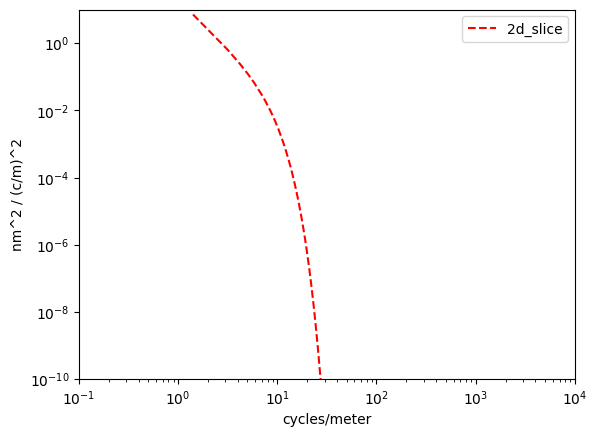

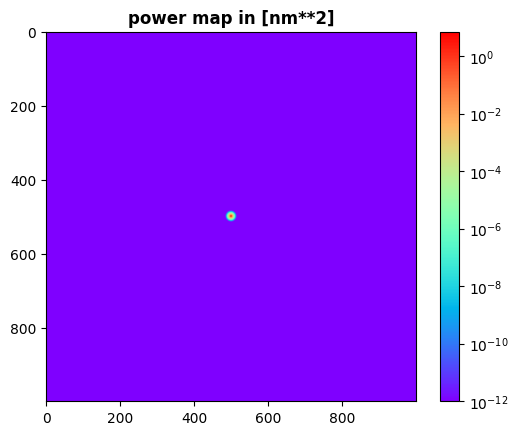

In [4]:
psd_tools = psd_utils.PSDUtils()

coords = psd_tools.coord_arrays((int(1000), int(1000)), dx=5e-4)

k = np.logspace(np.log10(0.15), np.log10(4e5), 200)  # [cycles/m]
k_min = np.min(k)
k_max = np.min(k)

psd = psd_tools.von_karman_psd(coords, 20.0, 6.5, 2.8,0.15 ,1.0e-12, rms=None, k_min=None, k_max=None, rms_scaling=True, only_1d =False) # generate PSD using von karman approach

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
x = psd.psd_1d_freqs
y = psd.psd_1d

ax.plot(x, y, label="2d_slice", color="red", linestyle="dashed")
ax.set_xlabel("cycles/meter")
ax.set_ylabel("nm^2 / (c/m)^2")

ax.set_yscale("log")
ax.set_xscale("log")
ax.set_ylim(bottom=1e-10, top=1e1)
ax.set_xlim(left=1e-1, right=1e4)

ax.legend()

plt.figure()

power = psd.psd_2d * coords.dk**2
im = plt.imshow(psd.psd_2d, cmap=cm.rainbow, norm=colors.LogNorm())
plt.title("power map in [nm**2]", fontweight="bold")
plt.colorbar(im)
plt.show()
 


## Generate OPD map from PSD

11/10/2025 03:24:35PM - __psd_utils__ - DEBUG - RMS of map at end of create_map is: 5.6422e+00
11/10/2025 03:24:35PM - __psd_utils__ - WARNING - Found zeros in map that aren't masked.


sigma is: 5.000 
RMS is: 5.000 
PTV is: 21.599 
Minimum value is: -11.353 
Maximum value is: 10.246 


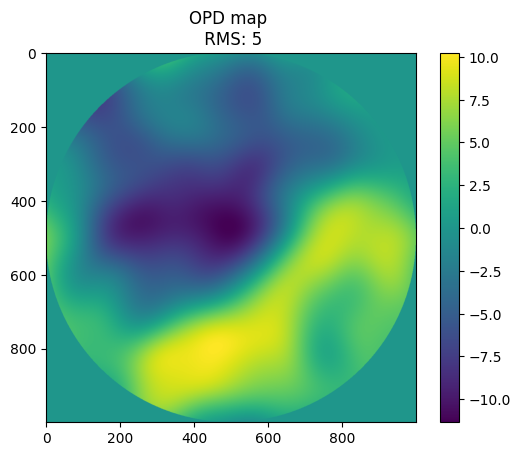

In [8]:
pupil_mask = np.zeros((int(1000), int(1000)))
pupil_mask[coords.r_grid < (0.5 / 2)] = 1
opd = psd_tools.create_map(coords, psd, mask=pupil_mask, rms=None)
stats_ab = psd_tools.get_map_stats(opd.map, mask = np.isfinite(opd.map), report=True)

#opd.map[opd.map == 0] = np.nan

plt.figure()
plt.title(f"OPD map \n RMS: {round(stats_ab.rms)}")
plt.imshow(opd.map)
plt.colorbar()

## Fit OPD map to 33 Bending Modes

Fit OPD map produced by PSD to 33 bending modes. Need to load in a force_space file and also bending mode package.

Not fitting modes: [33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165]
[-2.72499109 -2.16605952 -1.55559279 ...  5.12383251  5.08835776
  5.17687719]
sigma is: 3.666 
RMS is: 3.679 
PTV is: 18.627 
Minimum value is: -10.286 
Maximum value is: 8.341 


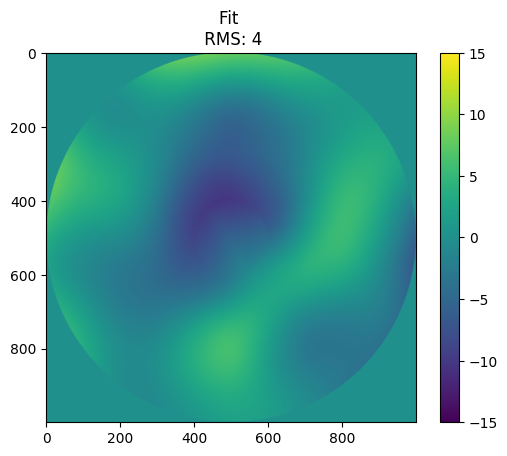

In [10]:
file_path = Path("C:/Users/solva/OneDrive - University of Arizona/Desktop/bending_mode/stp_tel_166_forcespace_mkII.mat")
force_space = ForceSpace(file_path)
b = Bending(file_path)

semi_dia = 3256.3
xlin = np.linspace(-semi_dia, semi_dia, opd.map.shape[0])
ylin = np.linspace(-semi_dia, semi_dia, opd.map.shape[1])
xc, yc = np.meshgrid(xlin, ylin)
eff_idx = ~np.isnan(opd.map)

mask = (opd.map != 0)

x_node = force_space.data["x_nodes"]
y_node = force_space.data["y_nodes"]

array_test = list(zip(x_node, y_node))
array_test = np.array(array_test)

fe_grid = RegularGridInterpolator((xlin, ylin), opd.map)
result = fe_grid(array_test)

rmsForces_bal, b_mode_fit, forces = b.fit_bending(modes_to_fit = np.arange(0, 33), map=result)
print(b_mode_fit)
#b_mode_fit_map = force_space.fea_to_grid(b_mode_fit, coords=coords, method="linear")
b_mode_fit_map = griddata((x_node, y_node), b_mode_fit, (xc, yc))
b_mode_fit_map = b_mode_fit_map

stats_fit = psd_tools.get_map_stats(b_mode_fit_map, mask = np.isfinite(b_mode_fit_map), report=True)
b_mode_fit_map = np.nan_to_num(b_mode_fit_map, nan=0)


plt.figure()
plt.imshow(b_mode_fit_map, vmin=-15, vmax=15)
plt.title(f"Fit \n RMS: {round(stats_fit.rms)}")
plt.colorbar()



## Generate PSD from bending mode fit map

In [14]:
meas_psd = psd_tools.measure_psd(b_mode_fit_map, coords=coords, mask=pupil_mask, max_rad=250)

psd_tools.create_plots(coords=coords, profiles=meas_psd, psd=psd, mask=pupil_mask, prefix='bmode_fit')

11/10/2025 04:11:05PM - __psd_utils__ - INFO - Using the coords array provided.
INFO:__psd_utils__:Using the coords array provided.
11/10/2025 04:11:06PM - __psd_utils__ - DEBUG - Measured total in generated profile: psd_pow1=np.float64(10.538460274544384)
DEBUG:__psd_utils__:Measured total in generated profile: psd_pow1=np.float64(10.538460274544384)
11/10/2025 04:11:06PM - __psd_utils__ - DEBUG - total theoretical profile area from integral = 791816.1097287538
DEBUG:__psd_utils__:total theoretical profile area from integral = 791816.1097287538
11/10/2025 04:11:06PM - __psd_utils__ - DEBUG - Total in theoretical profile: psd_pow2=np.float64(11.044378211731969)
DEBUG:__psd_utils__:Total in theoretical profile: psd_pow2=np.float64(11.044378211731969)
11/10/2025 04:11:06PM - __psd_utils__ - INFO - area scale is 9.542e-01
INFO:__psd_utils__:area scale is 9.542e-01
11/10/2025 04:11:06PM - __psd_utils__ - WARNING - Found zeros in map that aren't masked.
11/10/2025 04:11:06PM - __psd_utils__